In [5]:
# =========================================
# [셀 1] 환경 설정 + 거시지표 수집
# =========================================
# 목적:
#   - FRED API로 거시지표 수집
#   - S&P500 기반 레짐 지표 계산
#   - 비즈니스 사이클 레짐 분류용 데이터 확보
#
# 방법 1: 거시지표 (FRED)
#   - 실업률, 소비자심리, 스프레드, 금리, VIX
#
# 방법 2: S&P500 기반
#   - 이동평균 대비 위치
#   - 모멘텀 (3M, 6M, 12M)
#   - 변동성
#   - 고점/저점 대비 위치
#
# 산출물:
#   - data/interim/macro_indicators.parquet
#   - data/interim/market_regime_indicators.parquet

import os
from pathlib import Path
import pandas as pd
import numpy as np

# -----------------------------
# 경로 (SSOT)
# -----------------------------
QP2_ROOT = Path(r"C:\QP2")
INTERIM_DIR = QP2_ROOT / "data" / "interim"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

# =========================================
# [Part A] FRED 거시지표 수집
# =========================================
print("="*60)
print("[Part A] FRED 거시지표 수집")
print("="*60)

from fredapi import Fred

FRED_API_KEY = "8efc9e4ed1c9c3433ba70a995ede776c"
fred = Fred(api_key=FRED_API_KEY)

INDICATORS = {
    # 경기 사이클
    "UNRATE": "실업률",
    "INDPRO": "산업생산지수",
    "UMCSENT": "소비자심리지수",
    
    # 금융 조건
    "BAAFFM": "BAA스프레드",
    "T10Y2Y": "장단기금리차",
    "FEDFUNDS": "기준금리",
    
    # 시장
    "VIXCLS": "VIX",
}

print("\n📊 FRED 거시지표 수집 중...")

macro_data = {}
start_date = "2000-01-01"

for code, name in INDICATORS.items():
    try:
        series = fred.get_series(code, start_date)
        macro_data[code] = series
        print(f"✅ {code} ({name}): {len(series):,} rows")
    except Exception as e:
        print(f"❌ {code} ({name}): 실패 - {e}")

# 월말 리샘플링
macro_monthly = pd.DataFrame()
for code, series in macro_data.items():
    monthly = series.resample("ME").last()
    macro_monthly[code] = monthly

macro_monthly.index.name = "date"
macro_monthly = macro_monthly.sort_index().ffill()

# 저장
MACRO_PATH = INTERIM_DIR / "macro_indicators.parquet"
macro_monthly.to_parquet(MACRO_PATH)
print(f"\n💾 저장: {MACRO_PATH}")
print(f"   shape: {macro_monthly.shape}")
print(f"   기간: {macro_monthly.index.min().date()} ~ {macro_monthly.index.max().date()}")

# =========================================
# [Part B] S&P500 기반 레짐 지표
# =========================================
print("\n" + "="*60)
print("[Part B] S&P500 기반 레짐 지표")
print("="*60)

# 기존 Yahoo 데이터 로드 (벤치마크로 사용)
PX_WIDE_PATH = INTERIM_DIR / "yahoo_adjclose_wide.parquet"
px_wide = pd.read_parquet(PX_WIDE_PATH)

if px_wide.index.name != "date":
    if "date" in px_wide.columns:
        px_wide = px_wide.set_index("date")
px_wide.index = pd.to_datetime(px_wide.index)

# S&P500 동일가중 지수 생성 (벤치마크)
sp500_ew = px_wide.mean(axis=1)
sp500_ew.name = "SP500_EW"

print(f"✅ S&P500 동일가중 지수: {len(sp500_ew):,} days")

# 월말 리샘플링
sp500_m = sp500_ew.resample("ME").last()

# -----------------------------
# 레짐 지표 계산
# -----------------------------
print("\n📊 레짐 지표 계산 중...")

market_regime = pd.DataFrame(index=sp500_m.index)
market_regime["price"] = sp500_m

# 1) 이동평균 대비 위치
market_regime["ma_6m"] = sp500_m.rolling(6).mean()
market_regime["ma_12m"] = sp500_m.rolling(12).mean()
market_regime["price_vs_ma6"] = sp500_m / market_regime["ma_6m"] - 1
market_regime["price_vs_ma12"] = sp500_m / market_regime["ma_12m"] - 1

# 2) 모멘텀 (수익률)
market_regime["mom_1m"] = sp500_m.pct_change(1)
market_regime["mom_3m"] = sp500_m.pct_change(3)
market_regime["mom_6m"] = sp500_m.pct_change(6)
market_regime["mom_12m"] = sp500_m.pct_change(12)

# 3) 변동성 (일간 수익률 std, 월간으로 환산)
daily_ret = sp500_ew.pct_change()
monthly_vol = daily_ret.resample("ME").std() * np.sqrt(252)
market_regime["volatility"] = monthly_vol

# 4) 고점 대비 위치 (Drawdown)
rolling_max = sp500_m.cummax()
market_regime["drawdown"] = sp500_m / rolling_max - 1

# 5) 저점 대비 위치 (Rally from bottom)
rolling_min_12m = sp500_m.rolling(12).min()
market_regime["rally_from_low"] = sp500_m / rolling_min_12m - 1

# 6) 추세 방향 (MA 기울기)
market_regime["ma6_slope"] = market_regime["ma_6m"].pct_change(3)
market_regime["ma12_slope"] = market_regime["ma_12m"].pct_change(3)

# -----------------------------
# 레짐 분류 (단순 규칙 기반)
# -----------------------------
print("\n📊 레짐 분류...")

def classify_regime(row):
    """
    비즈니스 사이클 4단계 + 전환기
    
    레짐 정의:
    - 1_Crash: DD < -15%, 모멘텀 < -10%
    - 2_Contraction: MA 아래, 모멘텀 약함
    - 3_Recovery_Early: MA 아래, 모멘텀 강함 (급반등)
    - 4_Recovery_Late: MA 근처, 모멘텀 양수
    - 5_Expansion: MA 위, 모멘텀 양수
    - 6_Peak: MA 위, 모멘텀 약화
    """
    price_vs_ma = row["price_vs_ma12"]
    mom_6m = row["mom_6m"]
    dd = row["drawdown"]
    
    # NaN 처리
    if pd.isna(price_vs_ma) or pd.isna(mom_6m) or pd.isna(dd):
        return "0_Neutral"
    
    # 1) 급락기
    if dd < -0.15 and mom_6m < -0.10:
        return "1_Crash"
    
    # 2) 침체기
    if price_vs_ma < -0.05 and mom_6m < 0.05:
        return "2_Contraction"
    
    # 3) 회복 초기
    if price_vs_ma < 0 and mom_6m > 0.15:
        return "3_Recovery_Early"
    
    # 4) 회복 중후기
    if price_vs_ma >= -0.05 and price_vs_ma < 0.10 and mom_6m > 0:
        return "4_Recovery_Late"
    
    # 5) 확장기
    if price_vs_ma >= 0.05 and mom_6m > 0:
        return "5_Expansion"
    
    # 6) 고점/과열
    if price_vs_ma > 0.10 and mom_6m < 0.05:
        return "6_Peak"
    
    return "0_Neutral"

market_regime["regime"] = market_regime.apply(classify_regime, axis=1)

# 레짐 분포 확인
print("\n📊 레짐 분포:")
print(market_regime["regime"].value_counts().sort_index())

# 저장
REGIME_PATH = INTERIM_DIR / "market_regime_indicators.parquet"
market_regime.to_parquet(REGIME_PATH)
print(f"\n💾 저장: {REGIME_PATH}")

# =========================================
# [Part C] 두 데이터 병합
# =========================================
print("\n" + "="*60)
print("[Part C] 거시지표 + 시장지표 병합")
print("="*60)

# 공통 기간으로 병합
combined = market_regime.join(macro_monthly, how="inner")
print(f"✅ 병합 완료: {combined.shape}")
print(f"   기간: {combined.index.min().date()} ~ {combined.index.max().date()}")

# 저장
COMBINED_PATH = INTERIM_DIR / "regime_indicators_combined.parquet"
combined.to_parquet(COMBINED_PATH)
print(f"💾 저장: {COMBINED_PATH}")

# 미리보기
print("\n📋 최근 데이터:")
print(combined[["regime", "price_vs_ma12", "mom_6m", "drawdown", "UNRATE", "T10Y2Y"]].tail(10))

[Part A] FRED 거시지표 수집

📊 FRED 거시지표 수집 중...
✅ UNRATE (실업률): 312 rows
✅ INDPRO (산업생산지수): 312 rows
✅ UMCSENT (소비자심리지수): 312 rows
✅ BAAFFM (BAA스프레드): 312 rows
✅ T10Y2Y (장단기금리차): 6,805 rows
✅ FEDFUNDS (기준금리): 312 rows
✅ VIXCLS (VIX): 6,804 rows

💾 저장: C:\QP2\data\interim\macro_indicators.parquet
   shape: (312, 7)
   기간: 2000-01-31 ~ 2025-12-31

[Part B] S&P500 기반 레짐 지표
✅ S&P500 동일가중 지수: 16,127 days

📊 레짐 지표 계산 중...

📊 레짐 분류...

📊 레짐 분포:
regime
0_Neutral           128
1_Crash              59
2_Contraction        35
3_Recovery_Early      1
4_Recovery_Late     341
5_Expansion         204
6_Peak                1
Name: count, dtype: int64

💾 저장: C:\QP2\data\interim\market_regime_indicators.parquet

[Part C] 거시지표 + 시장지표 병합
✅ 병합 완료: (312, 22)
   기간: 2000-01-31 ~ 2025-12-31
💾 저장: C:\QP2\data\interim\regime_indicators_combined.parquet

📋 최근 데이터:
                     regime  price_vs_ma12    mom_6m  drawdown  UNRATE  T10Y2Y
date                                                                        

[셀 2] 레짐 분포 확인

📊 레짐 분포 (전체 기간):
regime
0_Neutral           44
1_Crash             21
2_Contraction       16
4_Recovery_Late    155
5_Expansion         76
Name: count, dtype: int64

   총 312 개월

📊 레짐별 기간 상세

Regime               Start        End            Months
-------------------------------------------------------
4_Recovery_Late      2000-01      2000-02             2
5_Expansion          2000-03      2000-03             1
4_Recovery_Late      2000-04      2000-07             4
5_Expansion          2000-08      2000-08             1
4_Recovery_Late      2000-09      2001-01             5
1_Crash              2001-02      2001-04             3
0_Neutral            2001-05      2001-07             3
2_Contraction        2001-08      2001-10             3
0_Neutral            2001-11      2002-01             3
4_Recovery_Late      2002-02      2002-04             3
0_Neutral            2002-05      2002-06             2
1_Crash              2002-07      2002-10             4
0_Neutra

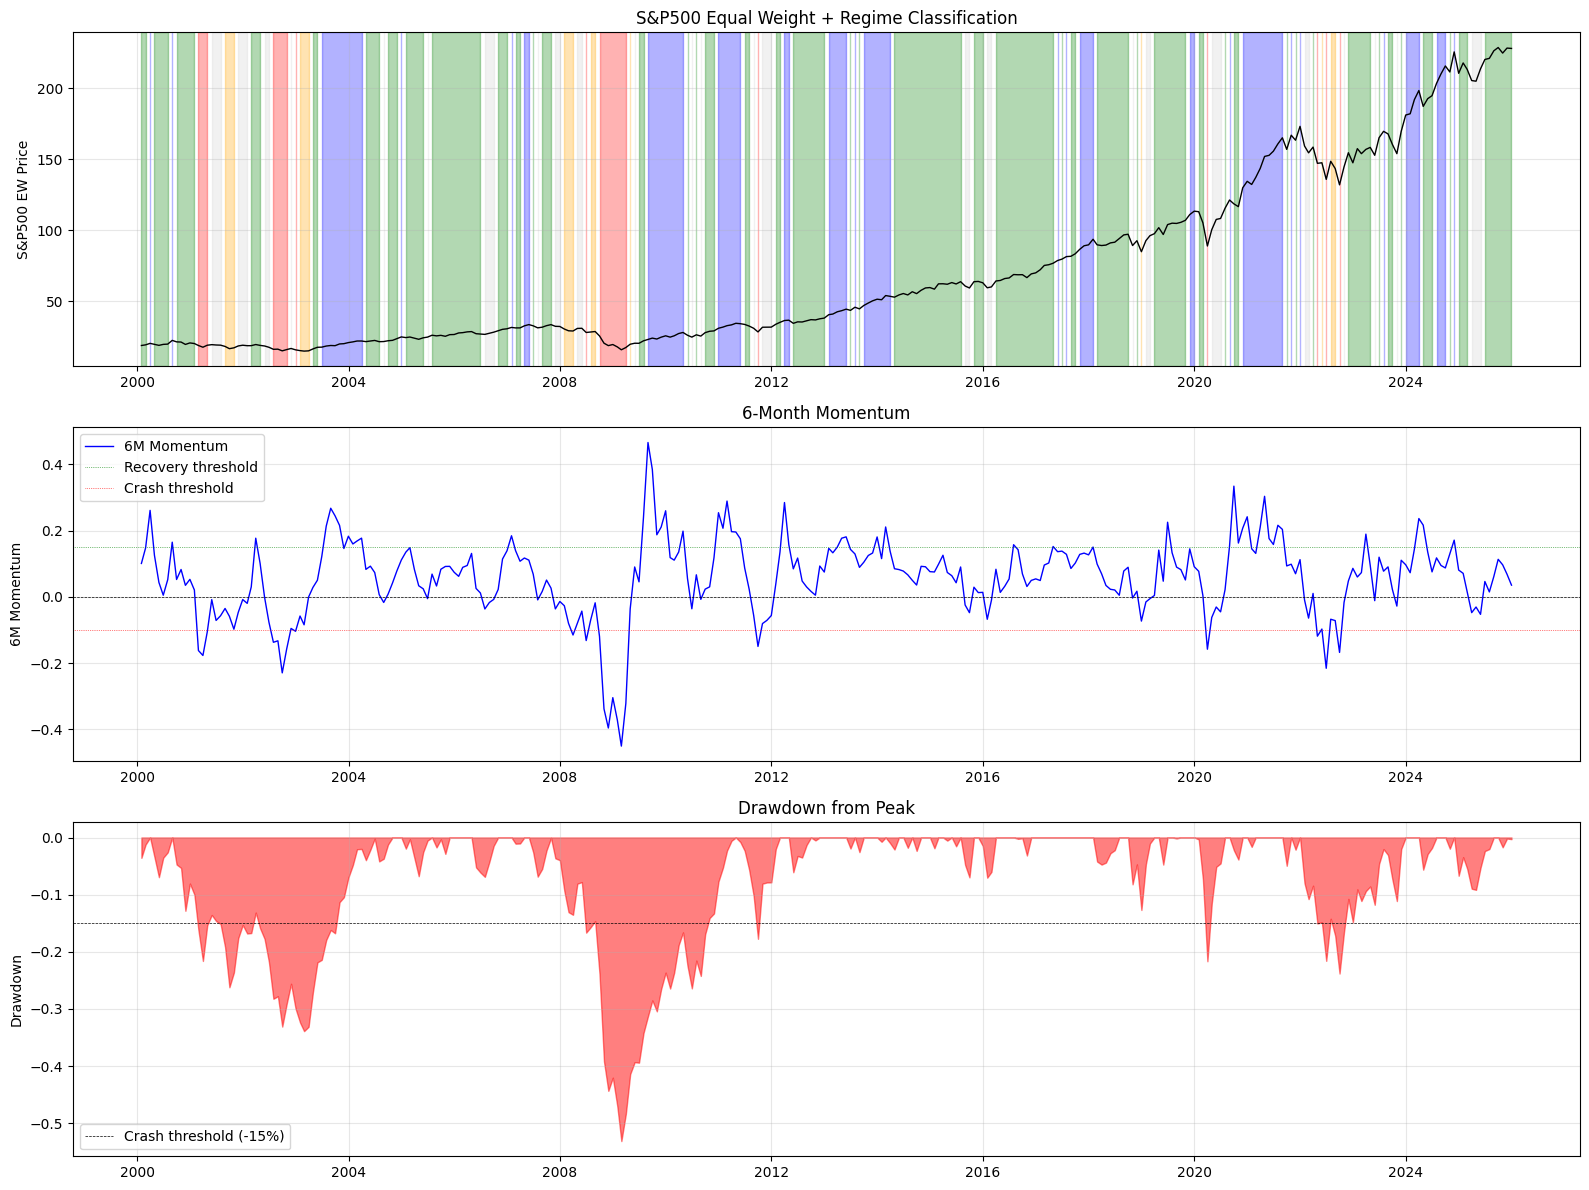

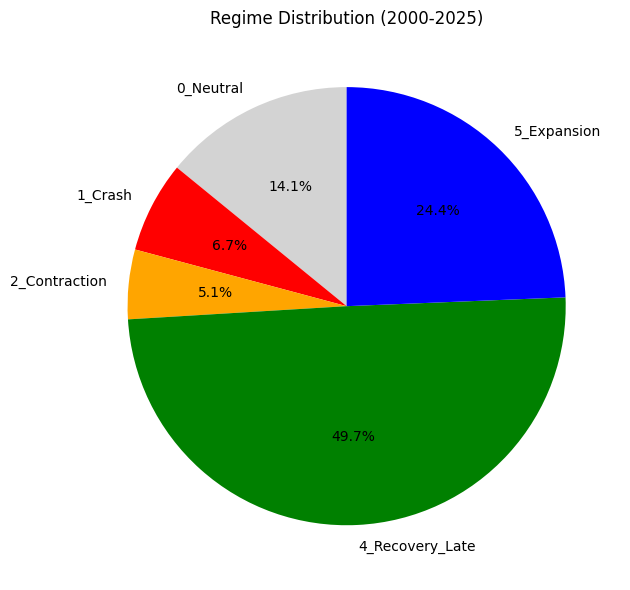


✅ 시각화 완료


In [6]:
# =========================================
# [셀 2] 레짐 분포 확인 + 시각화
# =========================================
# 목적:
#   - 레짐 분류 결과 확인
#   - 시계열로 레짐 변화 시각화
#   - 각 레짐별 기간 확인

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 데이터 로드
# -----------------------------
from pathlib import Path
QP2_ROOT = Path(r"C:\QP2")
INTERIM_DIR = QP2_ROOT / "data" / "interim"

combined = pd.read_parquet(INTERIM_DIR / "regime_indicators_combined.parquet")

print("="*60)
print("[셀 2] 레짐 분포 확인")
print("="*60)

# -----------------------------
# 레짐 분포
# -----------------------------
print("\n📊 레짐 분포 (전체 기간):")
print(combined["regime"].value_counts().sort_index())

print(f"\n   총 {len(combined)} 개월")

# -----------------------------
# 레짐별 기간 상세
# -----------------------------
print("\n" + "="*60)
print("📊 레짐별 기간 상세")
print("="*60)

# 연속된 레짐 구간 찾기
combined["regime_shift"] = combined["regime"] != combined["regime"].shift(1)
combined["regime_group"] = combined["regime_shift"].cumsum()

regime_periods = []
for group_id, group_df in combined.groupby("regime_group"):
    regime_periods.append({
        "regime": group_df["regime"].iloc[0],
        "start": group_df.index.min(),
        "end": group_df.index.max(),
        "months": len(group_df)
    })

regime_periods_df = pd.DataFrame(regime_periods)

print(f"\n{'Regime':<20} {'Start':<12} {'End':<12} {'Months':>8}")
print("-"*55)

for _, row in regime_periods_df.iterrows():
    print(f"{row['regime']:<20} {row['start'].strftime('%Y-%m'):<12} {row['end'].strftime('%Y-%m'):<12} {row['months']:>8}")

# -----------------------------
# 주요 이벤트 레짐 확인
# -----------------------------
print("\n" + "="*60)
print("📊 주요 이벤트 시점 레짐")
print("="*60)

events = {
    "GFC 바닥": "2009-03-31",
    "GFC 회복 중": "2009-09-30",
    "유럽위기": "2011-08-31",
    "차이나쇼크": "2016-02-29",
    "코로나 바닥": "2020-03-31",
    "코로나 회복": "2020-09-30",
    "금리인상 시작": "2022-03-31",
    "금리인상 피크": "2022-10-31",
    "현재": combined.index.max().strftime("%Y-%m-%d"),
}

print(f"\n{'이벤트':<20} {'날짜':<12} {'Regime':<20}")
print("-"*55)

for event_name, date_str in events.items():
    try:
        date = pd.to_datetime(date_str)
        # 가장 가까운 월말 찾기
        idx = combined.index[combined.index <= date].max()
        regime = combined.loc[idx, "regime"]
        print(f"{event_name:<20} {idx.strftime('%Y-%m'):<12} {regime:<20}")
    except:
        print(f"{event_name:<20} {'N/A':<12} {'N/A':<20}")

# -----------------------------
# 시각화
# -----------------------------
print("\n📊 시각화 생성 중...")

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 1) 가격 + 레짐 배경
ax1 = axes[0]
ax1.plot(combined.index, combined["price"], color="black", linewidth=1)
ax1.set_ylabel("S&P500 EW Price")
ax1.set_title("S&P500 Equal Weight + Regime Classification")

# 레짐별 색상
regime_colors = {
    "0_Neutral": "lightgray",
    "1_Crash": "red",
    "2_Contraction": "orange",
    "3_Recovery_Early": "lightgreen",
    "4_Recovery_Late": "green",
    "5_Expansion": "blue",
    "6_Peak": "purple",
}

# 배경 색칠
for _, row in regime_periods_df.iterrows():
    color = regime_colors.get(row["regime"], "white")
    ax1.axvspan(row["start"], row["end"], alpha=0.3, color=color)

ax1.grid(True, alpha=0.3)

# 2) 모멘텀 + 레짐
ax2 = axes[1]
ax2.plot(combined.index, combined["mom_6m"], color="blue", linewidth=1, label="6M Momentum")
ax2.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
ax2.axhline(y=0.15, color="green", linestyle=":", linewidth=0.5, label="Recovery threshold")
ax2.axhline(y=-0.10, color="red", linestyle=":", linewidth=0.5, label="Crash threshold")
ax2.set_ylabel("6M Momentum")
ax2.set_title("6-Month Momentum")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)

# 3) Drawdown
ax3 = axes[2]
ax3.fill_between(combined.index, combined["drawdown"], 0, color="red", alpha=0.5)
ax3.axhline(y=-0.15, color="black", linestyle="--", linewidth=0.5, label="Crash threshold (-15%)")
ax3.set_ylabel("Drawdown")
ax3.set_title("Drawdown from Peak")
ax3.legend(loc="lower left")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# 레짐 분포 파이차트
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

regime_counts = combined["regime"].value_counts().sort_index()
colors = [regime_colors.get(r, "gray") for r in regime_counts.index]

ax.pie(regime_counts, labels=regime_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title("Regime Distribution (2000-2025)")

plt.tight_layout()
plt.show()

print("\n✅ 시각화 완료")

[Cell 3] Regime Classification — Balanced Version

   Distribution (v2 balanced):
   0_Neutral              148 ( 19.2%)
   1_Crash                 42 (  5.5%)
   2_Recovery_Early        54 (  7.0%)
   3_Contraction           81 ( 10.5%)
   4_Recovery_Late        153 ( 19.9%)
   5_Expansion            249 ( 32.4%)
   6_Peak                  42 (  5.5%)

   Distribution (v3 with Trans):
   0_Neutral                   148 ( 19.2%)
   1_Crash                      40 (  5.2%)
   1_Crash_Trans                 2 (  0.3%)
   2_Recovery_Early             41 (  5.3%)
   2_Recovery_Early_Trans       13 (  1.7%)
   3_Contraction                66 (  8.6%)
   3_Contraction_Trans          15 (  2.0%)
   4_Recovery_Late             153 ( 19.9%)
   5_Expansion                 249 ( 32.4%)
   6_Peak                       42 (  5.5%)

Key Events Check

Event                v2                   v3                       
-----------------------------------------------------------------
GFC Peak          

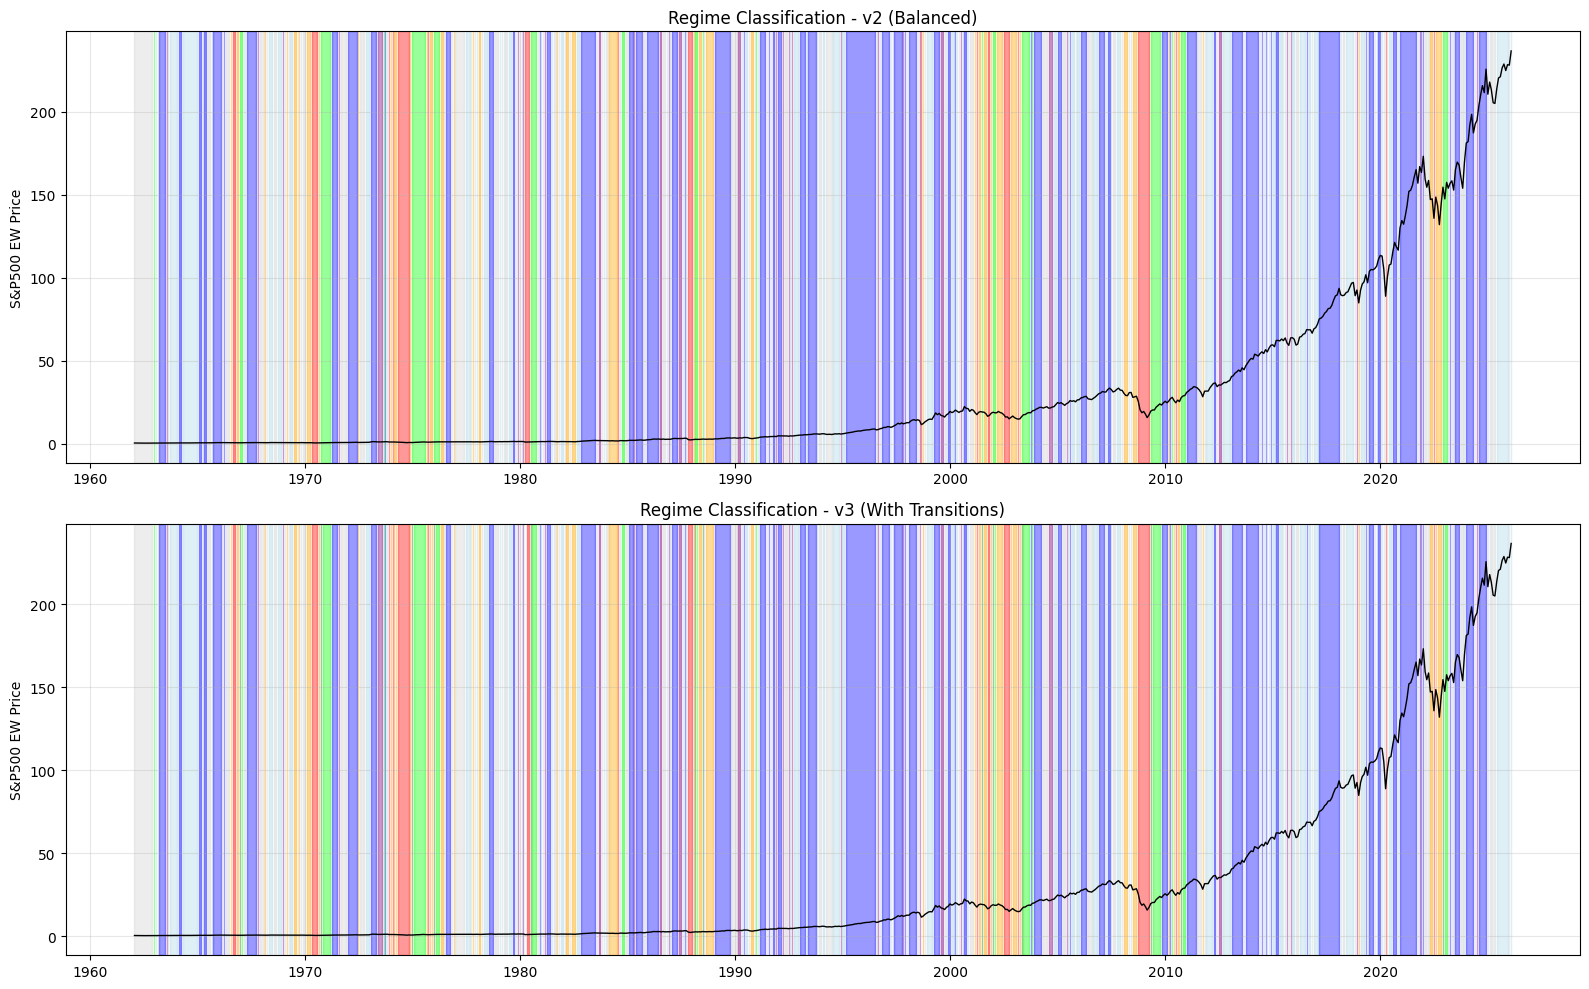


 Saved: C:\QP2\data\interim\market_regime_indicators.parquet
 Saved: C:\QP2\data\interim\regime_indicators_combined.parquet

 Done!


In [9]:
# =========================================
# [셀 3] 레짐 분류 — 균형 버전
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

QP2_ROOT = Path(r"C:\QP2")
INTERIM_DIR = QP2_ROOT / "data" / "interim"

market_regime = pd.read_parquet(INTERIM_DIR / "market_regime_indicators.parquet")
macro_monthly = pd.read_parquet(INTERIM_DIR / "macro_indicators.parquet")

print("="*60)
print("[Cell 3] Regime Classification — Balanced Version")
print("="*60)

# =========================================
# 균형 잡힌 조건
# =========================================

def classify_regime_balanced(row):
    """
    Balanced regime classification
    
    Target distribution (rough):
    - Crash: ~5% (15-20 months)
    - Recovery_Early: ~8% (25-30 months)
    - Contraction: ~8%
    - Recovery_Late: ~25%
    - Expansion: ~35%
    - Peak: ~5%
    - Neutral: ~15%
    """
    price_vs_ma = row["price_vs_ma12"]
    mom_3m = row["mom_3m"]
    mom_6m = row["mom_6m"]
    dd = row["drawdown"]
    rally = row["rally_from_low"]
    
    if pd.isna(price_vs_ma) or pd.isna(mom_6m) or pd.isna(dd):
        return "0_Neutral"
    
    # =====================
    # 1) Crash: 급락 진행 중
    # =====================
    if dd < -0.18 and mom_3m < -0.07:
        return "1_Crash"
    
    # =====================
    # 2) Recovery_Early: 바닥에서 급반등
    # =====================
    # DD 있지만 (-8% 이상) + 반등 중 (3M > 7%)
    if dd < -0.08 and mom_3m > 0.07:
        return "2_Recovery_Early"
    
    # 저점 대비 25% 이상 반등 + 아직 MA 아래
    if rally > 0.25 and price_vs_ma < 0 and mom_3m > 0.03:
        return "2_Recovery_Early"
    
    # =====================
    # 3) Contraction: 하락/침체 지속
    # =====================
    if price_vs_ma < -0.05 and mom_3m < 0.02:
        return "3_Contraction"
    
    if dd < -0.12 and mom_3m < 0.05 and mom_3m >= -0.07:
        return "3_Contraction"
    
    # =====================
    # 4) Recovery_Late: 회복 안정화
    # =====================
    if -0.05 <= price_vs_ma <= 0.08 and mom_3m > 0 and dd > -0.08:
        return "4_Recovery_Late"
    
    # =====================
    # 5) Expansion: 확장기
    # =====================
    if price_vs_ma > 0.05 and mom_3m > 0.02:
        return "5_Expansion"
    
    # =====================
    # 6) Peak: 고점, 모멘텀 약화
    # =====================
    if price_vs_ma > 0.05 and mom_3m < -0.01:
        return "6_Peak"
    
    if dd > -0.05 and price_vs_ma > 0 and mom_3m < 0.01 and mom_6m < 0.03:
        return "6_Peak"
    
    return "0_Neutral"

market_regime["regime_v2"] = market_regime.apply(classify_regime_balanced, axis=1)

print("\n   Distribution (v2 balanced):")
regime_dist = market_regime["regime_v2"].value_counts().sort_index()
total = len(market_regime)
for regime, count in regime_dist.items():
    pct = count / total * 100
    print(f"   {regime:<20} {count:>5} ({pct:>5.1f}%)")

# =========================================
# 방법 3: Trans (Crash ↔ Recovery 전환만)
# =========================================

def add_transition_flag_balanced(df, regime_col):
    """Mark major transitions"""
    df = df.copy()
    df["regime_v3"] = df[regime_col].copy()
    
    prev_regime = df[regime_col].shift(1)
    curr_regime = df[regime_col]
    
    # 주요 전환: Crash/Contraction → Recovery_Early
    major_transitions = [
        ("1_Crash", "2_Recovery_Early"),
        ("3_Contraction", "2_Recovery_Early"),
        ("1_Crash", "3_Contraction"),
        ("6_Peak", "1_Crash"),
        ("6_Peak", "3_Contraction"),
    ]
    
    for from_regime, to_regime in major_transitions:
        mask = (prev_regime == from_regime) & (curr_regime == to_regime)
        df.loc[mask, "regime_v3"] = to_regime + "_Trans"
    
    return df

market_regime = add_transition_flag_balanced(market_regime, "regime_v2")

print("\n   Distribution (v3 with Trans):")
regime_dist_v3 = market_regime["regime_v3"].value_counts().sort_index()
for regime, count in regime_dist_v3.items():
    pct = count / total * 100
    print(f"   {regime:<25} {count:>5} ({pct:>5.1f}%)")

# =========================================
# 주요 이벤트 확인
# =========================================
print("\n" + "="*60)
print("Key Events Check")
print("="*60)

events = {
    "GFC Peak": "2007-10-31",
    "GFC Crash": "2008-10-31",
    "GFC Bottom": "2009-03-31",
    "GFC Rebound 1M": "2009-04-30",
    "GFC Recovery": "2009-09-30",
    "Covid Crash": "2020-03-31",
    "Covid Rebound 1M": "2020-04-30",
    "Covid Recovery": "2020-09-30",
    "Rate Hike Peak": "2022-01-31",
    "Rate Hike Bottom": "2022-10-31",
}

print(f"\n{'Event':<20} {'v2':<20} {'v3':<25}")
print("-"*65)

for event_name, date_str in events.items():
    try:
        date = pd.to_datetime(date_str)
        idx = market_regime.index[market_regime.index <= date].max()
        v2 = market_regime.loc[idx, "regime_v2"]
        v3 = market_regime.loc[idx, "regime_v3"]
        print(f"{event_name:<20} {v2:<20} {v3:<25}")
    except:
        print(f"{event_name:<20} {'N/A':<20} {'N/A':<25}")

# =========================================
# 시각화
# =========================================
print("\n Generating charts...")

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

regime_colors = {
    "0_Neutral": "lightgray",
    "1_Crash": "red",
    "2_Recovery_Early": "lime",
    "2_Recovery_Early_Trans": "green",
    "3_Contraction": "orange",
    "3_Contraction_Trans": "darkorange",
    "4_Recovery_Late": "lightblue",
    "5_Expansion": "blue",
    "6_Peak": "purple",
}

for ax_idx, (regime_col, title) in enumerate([
    ("regime_v2", "v2 (Balanced)"),
    ("regime_v3", "v3 (With Transitions)")
]):
    ax = axes[ax_idx]
    ax.plot(market_regime.index, market_regime["price"], color="black", linewidth=1)
    ax.set_ylabel("S&P500 EW Price")
    ax.set_title(f"Regime Classification - {title}")
    
    market_regime["_shift"] = market_regime[regime_col] != market_regime[regime_col].shift(1)
    market_regime["_group"] = market_regime["_shift"].cumsum()
    
    for group_id, group_df in market_regime.groupby("_group"):
        regime = group_df[regime_col].iloc[0]
        color = regime_colors.get(regime, "white")
        ax.axvspan(group_df.index.min(), group_df.index.max(), alpha=0.4, color=color)
    
    ax.grid(True, alpha=0.3)

market_regime.drop(columns=["_shift", "_group"], inplace=True)

plt.tight_layout()
plt.show()

# =========================================
# 저장
# =========================================
market_regime["regime_final"] = market_regime["regime_v3"]

REGIME_PATH = INTERIM_DIR / "market_regime_indicators.parquet"
market_regime.to_parquet(REGIME_PATH)
print(f"\n Saved: {REGIME_PATH}")

combined = market_regime.join(macro_monthly, how="inner")
COMBINED_PATH = INTERIM_DIR / "regime_indicators_combined.parquet"
combined.to_parquet(COMBINED_PATH)
print(f" Saved: {COMBINED_PATH}")

print("\n Done!")

[Cell 4] Macro-based Regime Classification (Method 1)

 Macro data: 312 months
 Columns: ['UNRATE', 'INDPRO', 'UMCSENT', 'BAAFFM', 'T10Y2Y', 'FEDFUNDS', 'VIXCLS']

 Calculating macro signals...
   Signals calculated

 Classifying regimes (macro only)...

 Macro Regime Distribution:
   0_Neutral               77 ( 24.7%)
   1_Crash                 25 (  8.0%)
   2_Recovery_Early        84 ( 26.9%)
   3_Contraction           17 (  5.4%)
   4_Recovery_Late         28 (  9.0%)
   5_Expansion             44 ( 14.1%)
   6_Peak                  37 ( 11.9%)

Key Events - Macro Regime

Event                Macro Regime           UNRATE   T10Y2Y
------------------------------------------------------------
Dotcom Peak          0_Neutral                 4.0    -0.47
Dotcom Bottom        0_Neutral                 5.7     2.25
GFC Start            0_Neutral                 6.1     1.85
GFC Bottom           1_Crash                   8.7     1.90
GFC Recovery         0_Neutral                 9.8     

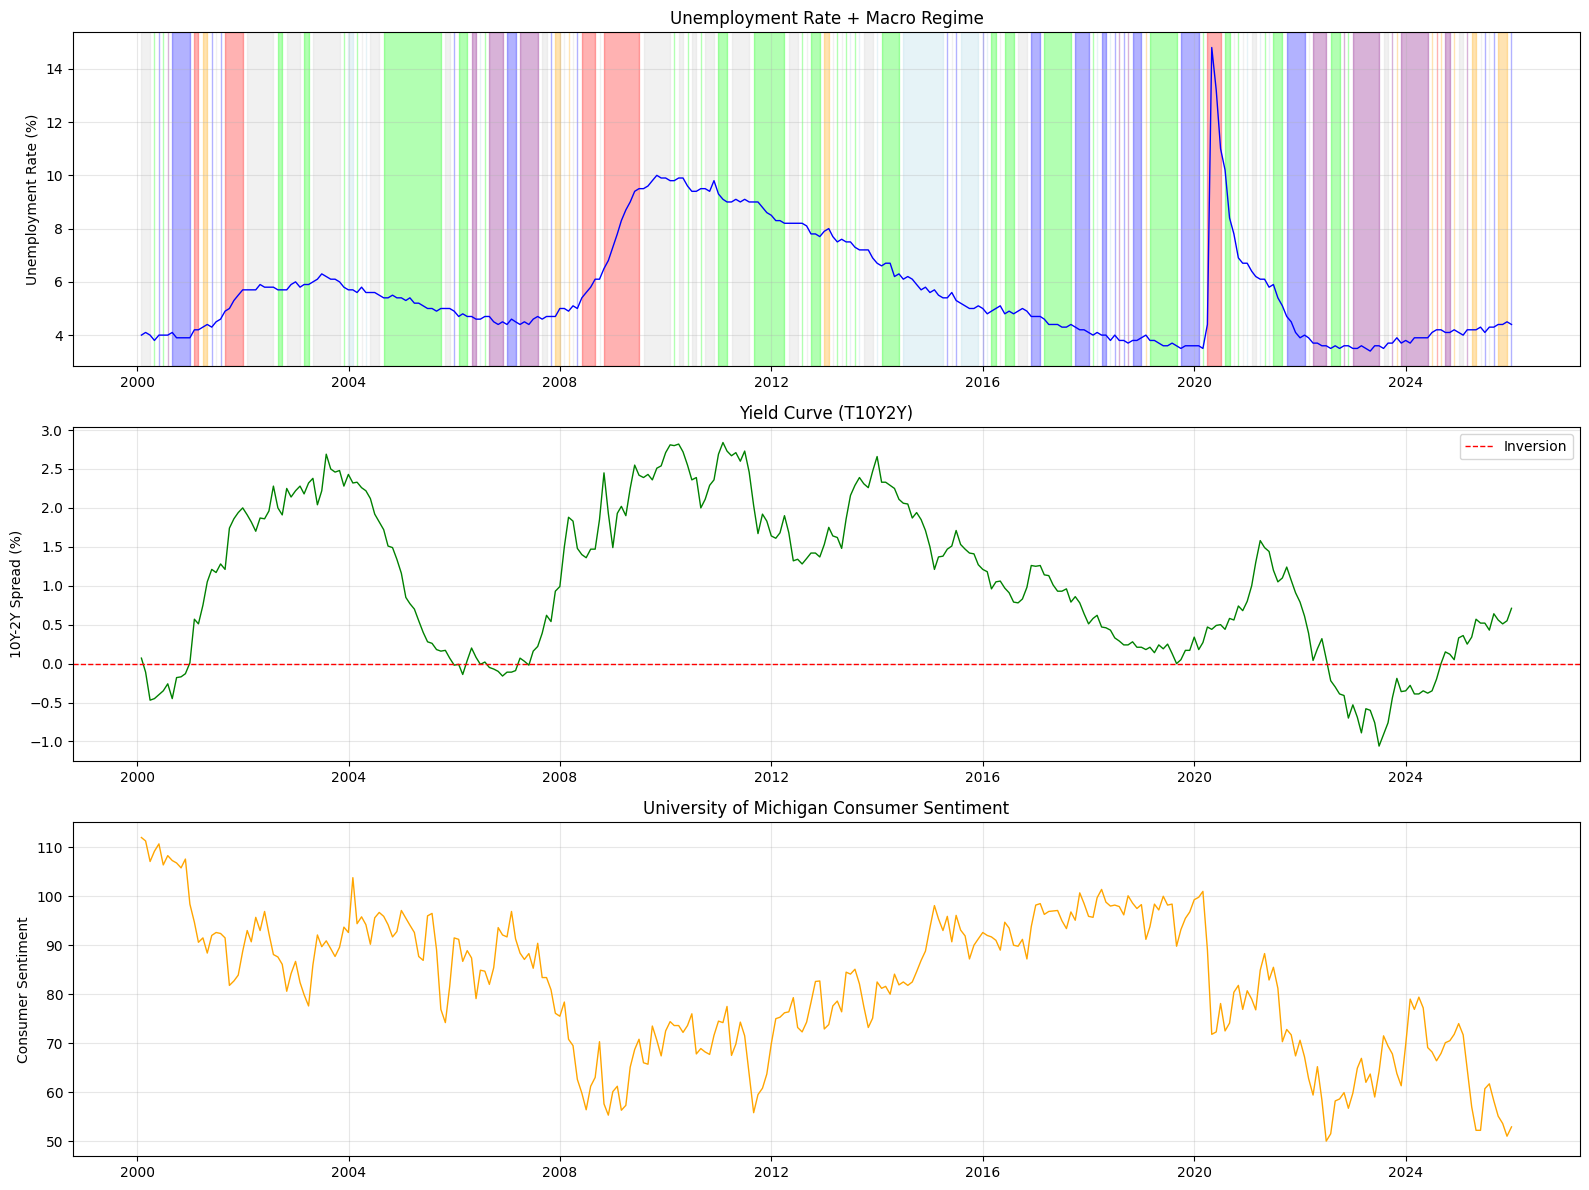


 Saved with regime_macro

 Done!


In [11]:
# =========================================
# [셀 4] 거시지표 기반 레짐 분류 (방법 1)
# =========================================
# 목적:
#   - FRED 거시지표만으로 레짐 분류
#   - S&P500 가격 정보 사용 안 함
#
# 지표:
#   - UNRATE: 실업률 (경기 후행)
#   - T10Y2Y: 장단기 금리차 (경기 선행, 역전 시 침체 신호)
#   - FEDFUNDS: 기준금리 (통화정책)
#   - BAAFFM: BAA 스프레드 (리스크 프리미엄)
#   - UMCSENT: 소비자심리 (경기 동행)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

QP2_ROOT = Path(r"C:\QP2")
INTERIM_DIR = QP2_ROOT / "data" / "interim"

# -----------------------------
# 데이터 로드
# -----------------------------
print("="*60)
print("[Cell 4] Macro-based Regime Classification (Method 1)")
print("="*60)

macro = pd.read_parquet(INTERIM_DIR / "macro_indicators.parquet")
print(f"\n Macro data: {len(macro)} months")
print(f" Columns: {list(macro.columns)}")

# -----------------------------
# 거시지표 변화율/레벨 계산
# -----------------------------
print("\n Calculating macro signals...")

# 실업률 변화 (3개월)
macro["UNRATE_chg3m"] = macro["UNRATE"] - macro["UNRATE"].shift(3)
macro["UNRATE_chg6m"] = macro["UNRATE"] - macro["UNRATE"].shift(6)

# 장단기 금리차 (이미 레벨)
# T10Y2Y < 0 → 역전 → 침체 신호

# 기준금리 변화
macro["FEDFUNDS_chg3m"] = macro["FEDFUNDS"] - macro["FEDFUNDS"].shift(3)
macro["FEDFUNDS_chg6m"] = macro["FEDFUNDS"] - macro["FEDFUNDS"].shift(6)

# BAA 스프레드 변화 (리스크)
macro["BAAFFM_chg3m"] = macro["BAAFFM"] - macro["BAAFFM"].shift(3)

# 소비자심리 변화
macro["UMCSENT_chg3m"] = macro["UMCSENT"] - macro["UMCSENT"].shift(3)

print("   Signals calculated")

# -----------------------------
# 거시지표 기반 레짐 분류
# -----------------------------
print("\n Classifying regimes (macro only)...")

def classify_macro_regime(row):
    """
    거시지표만으로 레짐 분류
    
    1) Crash: 실업률 급등 + 스프레드 급등 + 심리 급락
    2) Recovery_Early: 실업률 고점 찍고 하락 시작 + 심리 반등
    3) Contraction: 실업률 상승 중 + 금리차 역전/낮음
    4) Recovery_Late: 실업률 하락 중 + 심리 회복
    5) Expansion: 실업률 낮고 안정 + 심리 좋음
    6) Peak: 실업률 바닥 + 금리 인상 중 + 금리차 축소
    """
    unrate = row["UNRATE"]
    unrate_chg3m = row["UNRATE_chg3m"]
    unrate_chg6m = row["UNRATE_chg6m"]
    t10y2y = row["T10Y2Y"]
    fedfunds_chg3m = row["FEDFUNDS_chg3m"]
    baaffm = row["BAAFFM"]
    baaffm_chg3m = row["BAAFFM_chg3m"]
    umcsent = row["UMCSENT"]
    umcsent_chg3m = row["UMCSENT_chg3m"]
    
    # NaN 처리
    if pd.isna(unrate_chg3m) or pd.isna(t10y2y):
        return "0_Neutral"
    
    # =====================
    # 1) Crash: 위기 진행 중
    # =====================
    # 실업률 급등 (3개월간 +0.5%p 이상) + 스프레드 높음
    if unrate_chg3m > 0.5 and baaffm > 2.0:
        return "1_Crash"
    
    # 실업률 급등 + 심리 급락
    if unrate_chg3m > 0.3 and umcsent_chg3m < -10:
        return "1_Crash"
    
    # =====================
    # 2) Recovery_Early: 위기 후 초기 회복
    # =====================
    # 실업률 높지만 (7% 이상) 하락 시작 + 심리 반등
    if unrate > 6.0 and unrate_chg3m < 0 and umcsent_chg3m > 5:
        return "2_Recovery_Early"
    
    # 스프레드 높았다가 하락 중 + 실업률 안정화
    if baaffm > 1.5 and baaffm_chg3m < -0.3 and unrate_chg3m <= 0:
        return "2_Recovery_Early"
    
    # =====================
    # 3) Contraction: 침체/하락 지속
    # =====================
    # 실업률 상승 중 + 금리차 낮음/역전
    if unrate_chg6m > 0.3 and t10y2y < 0.5:
        return "3_Contraction"
    
    # 실업률 상승 + 심리 하락
    if unrate_chg3m > 0.1 and umcsent_chg3m < -5:
        return "3_Contraction"
    
    # =====================
    # 4) Recovery_Late: 회복 안정화
    # =====================
    # 실업률 하락 중 + 심리 양호
    if unrate_chg6m < -0.3 and umcsent > 80:
        return "4_Recovery_Late"
    
    # 실업률 하락 + 스프레드 정상
    if unrate_chg3m < 0 and baaffm < 1.5 and unrate > 4.5:
        return "4_Recovery_Late"
    
    # =====================
    # 5) Expansion: 확장기
    # =====================
    # 실업률 낮고 안정 + 심리 좋음
    if unrate < 5.0 and abs(unrate_chg3m) < 0.2 and umcsent > 90:
        return "5_Expansion"
    
    # 실업률 낮음 + 금리차 정상
    if unrate < 5.5 and unrate_chg3m <= 0 and t10y2y > 0.5:
        return "5_Expansion"
    
    # =====================
    # 6) Peak: 고점/과열
    # =====================
    # 실업률 바닥권 + 금리 인상 중 + 금리차 축소
    if unrate < 4.5 and fedfunds_chg3m > 0.3 and t10y2y < 1.0:
        return "6_Peak"
    
    # 금리차 역전 임박
    if t10y2y < 0.3 and t10y2y > -0.5 and unrate < 5.0:
        return "6_Peak"
    
    return "0_Neutral"

macro["regime_macro"] = macro.apply(classify_macro_regime, axis=1)

# -----------------------------
# 분포 확인
# -----------------------------
print("\n Macro Regime Distribution:")
regime_dist = macro["regime_macro"].value_counts().sort_index()
total = len(macro.dropna(subset=["regime_macro"]))
for regime, count in regime_dist.items():
    pct = count / total * 100
    print(f"   {regime:<20} {count:>5} ({pct:>5.1f}%)")

# -----------------------------
# 주요 이벤트 확인
# -----------------------------
print("\n" + "="*60)
print("Key Events - Macro Regime")
print("="*60)

events = {
    "Dotcom Peak": "2000-03-31",
    "Dotcom Bottom": "2002-10-31",
    "GFC Start": "2008-09-30",
    "GFC Bottom": "2009-03-31",
    "GFC Recovery": "2009-09-30",
    "Covid Crash": "2020-03-31",
    "Covid Recovery": "2020-09-30",
    "Rate Hike Start": "2022-01-31",
    "Rate Hike Bottom": "2022-10-31",
}

print(f"\n{'Event':<20} {'Macro Regime':<20} {'UNRATE':>8} {'T10Y2Y':>8}")
print("-"*60)

for event_name, date_str in events.items():
    try:
        date = pd.to_datetime(date_str)
        idx = macro.index[macro.index <= date].max()
        regime = macro.loc[idx, "regime_macro"]
        unrate = macro.loc[idx, "UNRATE"]
        t10y2y = macro.loc[idx, "T10Y2Y"]
        print(f"{event_name:<20} {regime:<20} {unrate:>8.1f} {t10y2y:>8.2f}")
    except:
        print(f"{event_name:<20} {'N/A':<20}")

# -----------------------------
# S&P500 기반 vs 거시지표 기반 비교
# -----------------------------
print("\n" + "="*60)
print("Comparison: S&P500-based vs Macro-based")
print("="*60)

# S&P500 레짐 로드
market_regime = pd.read_parquet(INTERIM_DIR / "market_regime_indicators.parquet")

# 병합
comparison = macro[["regime_macro"]].join(market_regime[["regime_v2"]], how="inner")

print(f"\n{'Event':<20} {'S&P500 (v2)':<20} {'Macro':<20}")
print("-"*60)

for event_name, date_str in events.items():
    try:
        date = pd.to_datetime(date_str)
        idx = comparison.index[comparison.index <= date].max()
        sp_regime = comparison.loc[idx, "regime_v2"]
        macro_regime = comparison.loc[idx, "regime_macro"]
        print(f"{event_name:<20} {sp_regime:<20} {macro_regime:<20}")
    except:
        print(f"{event_name:<20} {'N/A':<20} {'N/A':<20}")

# -----------------------------
# 시각화
# -----------------------------
print("\n Generating charts...")

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 1) 실업률 + 레짐
ax1 = axes[0]
ax1.plot(macro.index, macro["UNRATE"], color="blue", linewidth=1)
ax1.set_ylabel("Unemployment Rate (%)")
ax1.set_title("Unemployment Rate + Macro Regime")

regime_colors = {
    "0_Neutral": "lightgray",
    "1_Crash": "red",
    "2_Recovery_Early": "lime",
    "3_Contraction": "orange",
    "4_Recovery_Late": "lightblue",
    "5_Expansion": "blue",
    "6_Peak": "purple",
}

macro["_shift"] = macro["regime_macro"] != macro["regime_macro"].shift(1)
macro["_group"] = macro["_shift"].cumsum()

for group_id, group_df in macro.groupby("_group"):
    regime = group_df["regime_macro"].iloc[0]
    color = regime_colors.get(regime, "white")
    ax1.axvspan(group_df.index.min(), group_df.index.max(), alpha=0.3, color=color)

ax1.grid(True, alpha=0.3)

# 2) 장단기 금리차
ax2 = axes[1]
ax2.plot(macro.index, macro["T10Y2Y"], color="green", linewidth=1)
ax2.axhline(y=0, color="red", linestyle="--", linewidth=1, label="Inversion")
ax2.set_ylabel("10Y-2Y Spread (%)")
ax2.set_title("Yield Curve (T10Y2Y)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3) 소비자심리
ax3 = axes[2]
ax3.plot(macro.index, macro["UMCSENT"], color="orange", linewidth=1)
ax3.set_ylabel("Consumer Sentiment")
ax3.set_title("University of Michigan Consumer Sentiment")
ax3.grid(True, alpha=0.3)

macro.drop(columns=["_shift", "_group"], inplace=True)

plt.tight_layout()
plt.show()

# -----------------------------
# 저장
# -----------------------------
macro.to_parquet(INTERIM_DIR / "macro_indicators.parquet")
print(f"\n Saved with regime_macro")

print("\n Done!")

In [12]:
# =========================================
# [셀 5] 레짐 분류 방법 정리 (Summary)
# =========================================
#
# =============================================================================
# REGIME CLASSIFICATION METHODS — SUMMARY
# =============================================================================
#
# 1. 개요
# -------
# 목적: 비즈니스 사이클 기반으로 시장 레짐 분류
# 용도: 팩터 타이밍 전략 (레짐별 팩터 유효성 검증)
#
# 분류된 레짐:
#     0_Neutral: 애매한 구간 (조건 미충족)
#     1_Crash: 급락 진행 중
#     2_Recovery_Early: 바닥 찍고 급반등
#     3_Contraction: 하락/침체 지속
#     4_Recovery_Late: 회복 안정화
#     5_Expansion: 확장기 (좋은 시기)
#     6_Peak: 고점, 모멘텀 약화
#
#
# =============================================================================
# 2. 방법별 분류 기준
# =============================================================================
#
# [방법 1] 거시지표 기반 (Macro-based)
# -------------------------------------
# 사용 지표:
#     UNRATE: 실업률 (후행)
#     T10Y2Y: 장단기 금리차 (선행)
#     BAAFFM: BAA 신용 스프레드 (동행)
#     UMCSENT: 소비자 심리지수 (동행)
#     FEDFUNDS: 기준금리 (동행)
#
# 분류 기준:
#     1_Crash:
#         실업률 3M 변화 > +0.5%p AND 스프레드 > 2.0%
#         또는: 실업률 3M 변화 > +0.3%p AND 심리 3M 변화 < -10
#
#     2_Recovery_Early:
#         실업률 > 6% AND 실업률 하락 시작 AND 심리 반등 (+5 이상)
#         또는: 스프레드 > 1.5% AND 스프레드 하락 중 AND 실업률 안정
#
#     3_Contraction:
#         실업률 6M 변화 > +0.3%p AND 금리차 < 0.5%
#         또는: 실업률 상승 AND 심리 하락
#
#     4_Recovery_Late:
#         실업률 6M 변화 < -0.3%p AND 심리 > 80
#
#     5_Expansion:
#         실업률 < 5% AND 안정적 (변화 < +-0.2%p) AND 심리 > 90
#
#     6_Peak:
#         실업률 < 4.5% AND 금리 인상 중 AND 금리차 < 1.0%
#         또는: 금리차 역전 임박 (< 0.3%) AND 실업률 낮음
#
#
# [방법 2] S&P500 기반 (Market-based)
# -----------------------------------
# 사용 지표:
#     price_vs_ma12: 현재가 / 12개월 MA - 1
#     mom_3m: 3개월 수익률
#     mom_6m: 6개월 수익률
#     drawdown: 고점 대비 하락률
#     rally_from_low: 저점 대비 상승률
#
# 분류 기준:
#     1_Crash:
#         DD < -18% AND mom_3m < -7%
#
#     2_Recovery_Early:
#         DD < -8% AND mom_3m > +7%
#         또는: 저점 대비 +25% 반등 AND MA 아래 AND mom_3m > +3%
#
#     3_Contraction:
#         MA 대비 -5% 아래 AND mom_3m < +2%
#         또는: DD < -12% AND mom_3m 약함 (0 ~ -7%)
#
#     4_Recovery_Late:
#         MA 대비 -5% ~ +8% AND mom_3m > 0 AND DD > -8%
#
#     5_Expansion:
#         MA 대비 +5% 위 AND mom_3m > +2%
#
#     6_Peak:
#         MA 대비 +5% 위 AND mom_3m < -1%
#
#
# [방법 3] 전환 초기 분리 (Transition)
# ------------------------------------
# 방법 2 기반 + 주요 전환점 첫 1개월에 "_Trans" 표시
#
# Trans 조건:
#     1_Crash_Trans: 어디서든 -> Crash 진입 첫 달
#     2_Recovery_Early_Trans: Crash/Contraction -> Recovery_Early 첫 달
#     3_Contraction_Trans: Crash -> Contraction 첫 달
#
# 목적: 전환 초기 급변동 구간을 분리해서 팩터 효과 별도 분석
#
#
# =============================================================================
# 3. 방법별 분포 비교 (2000-2025, 약 312개월 기준)
# =============================================================================
#
# 레짐               방법1(거시)      방법2(S&P500)    차이
# -----------------------------------------------------------------
# 0_Neutral          77 (24.7%)      148 (19.2%)      거시: Neutral 더 적음
# 1_Crash            25 ( 8.0%)       42 ( 5.5%)      거시: Crash 더 많음
# 2_Recovery_Early   84 (26.9%)       54 ( 7.0%)      거시: 훨씬 많음 (후행 때문)
# 3_Contraction      17 ( 5.4%)       81 (10.5%)      S&P500: 더 많음
# 4_Recovery_Late    28 ( 9.0%)      153 (19.9%)      S&P500: 더 많음
# 5_Expansion        44 (14.1%)      249 (32.4%)      S&P500: 훨씬 많음
# 6_Peak             37 (11.9%)       42 ( 5.5%)      비슷
#
#
# =============================================================================
# 4. 방법간 레짐 판단이 다른 주요 사례
# =============================================================================
#
# 이벤트              S&P500 (v2)          거시지표              원인
# ----------------------------------------------------------------------------------
# GFC Bottom          1_Crash              2_Recovery_Early      실업률 후행
# (2009-03)           (아직 급락 중)        (실업률 이미 고점)    (시장이 먼저 반응)
#
# Covid Rebound       2_Recovery_Early     1_Crash               실업률 후행
# (2020-04)           (반등 시작)           (실업률 14.7% 급등)   (시장이 먼저 반등)
#
# Rate Hike Start     5_Expansion          0_Neutral             판단 기준 차이
# (2022-01)           (MA 위, 모멘텀 양수)  (조건 미충족)
#
# Rate Hike Bottom    6_Peak               3_Contraction         해석 차이
# (2022-10)           (모멘텀 약화)         (실업률 상승 중)
#
#
# =============================================================================
# 5. 각 방법의 한계
# =============================================================================
#
# [방법 1] 거시지표 기반
# ----------------------
# 장점:
#     - 펀더멘털 기반 (이론적 근거)
#     - 경제 상황 직접 반영
#
# 한계:
#     - 실업률 = 후행지표 -> 시장보다 늦게 반응
#     - 예측용으로 부적합 (과거 분류용으로만)
#     - Recovery_Early가 과다 잡힘 (27% vs 7%)
#     - 금리차(T10Y2Y)만 선행, 나머지는 후행/동행
#
# 개선 방향:
#     - 예측용이라면 실업률 제외
#     - 금리차 + 스프레드 + VIX 위주로 재구성
#
#
# [방법 2] S&P500 기반
# --------------------
# 장점:
#     - 시장 반응 즉시 반영
#     - 실시간 판단 가능
#     - 팩터 테스트에 직접 사용 가능
#
# 한계:
#     - 미래정보 사용 위험 (백테스트 시 주의)
#     - MA, 모멘텀 = 후행 계산 (look-ahead bias 가능)
#     - 노이즈에 민감 (레짐이 자주 바뀜)
#     - Neutral이 많음 (19%)
#
# 개선 방향:
#     - 레짐 전환 시 확인 기간 추가 (1개월 유지 후 전환)
#     - 거시지표와 결합해서 확인
#
#
# [방법 3] 전환 초기 분리
# -----------------------
# 장점:
#     - 급변동 구간 별도 분석 가능
#     - 팩터 효과가 다를 수 있는 구간 식별
#
# 한계:
#     - 방법 2에 의존 (방법 2 한계 그대로 상속)
#     - Trans 개월수가 적어서 통계적 유의성 부족할 수 있음
#
#
# =============================================================================
# 6. 결론 및 다음 단계
# =============================================================================
#
# 현재 상태:
#     - 방법 1 (거시지표): regime_macro 컬럼
#     - 방법 2 (S&P500): regime_v2 컬럼
#     - 방법 3 (전환분리): regime_v3 컬럼
#
# 다음 단계:
#     - 방법 4: 방법 1 + 방법 2 조합
#     - Value 팩터 테스트 (레짐별 성과 검증)
#
# 저장 위치:
#     - data/interim/macro_indicators.parquet (거시지표 + regime_macro)
#     - data/interim/market_regime_indicators.parquet (S&P500 + regime_v2, v3)
#     - data/interim/regime_indicators_combined.parquet (전체 병합)
#
# =============================================================================

print("Cell 5: Summary cell (documentation only)")
print("No computation — see comments above")

Cell 5: Summary cell (documentation only)
No computation — see comments above


[Cell 6] Method 4: Macro + S&P500 Combined

 Combined data: 312 months

 Applying combination rules...

Combined Regime Distribution

Regime                          Count      Pct
--------------------------------------------------
0_Neutral_Confirmed                10 (  3.2%)
0_Neutral_Unconfirmed              41 ( 13.1%)
1_Crash_Confirmed                   9 (  2.9%)
1_Crash_Early                       5 (  1.6%)
1_Crash_Unconfirmed                 4 (  1.3%)
2_Recovery_Early                    4 (  1.3%)
2_Recovery_Early_Confirmed          1 (  0.3%)
2_Recovery_Early_Unconfirmed       17 (  5.4%)
3_Contraction                      14 (  4.5%)
3_Contraction_Confirmed             2 (  0.6%)
3_Contraction_Unconfirmed          17 (  5.4%)
4_Recovery_Late_Confirmed          28 (  9.0%)
4_Recovery_Late_Unconfirmed        44 ( 14.1%)
5_Expansion                        51 ( 16.3%)
5_Expansion_Confirmed              13 (  4.2%)
5_Expansion_Unconfirmed            27 (  8.7%)
5_Expansion_Warn

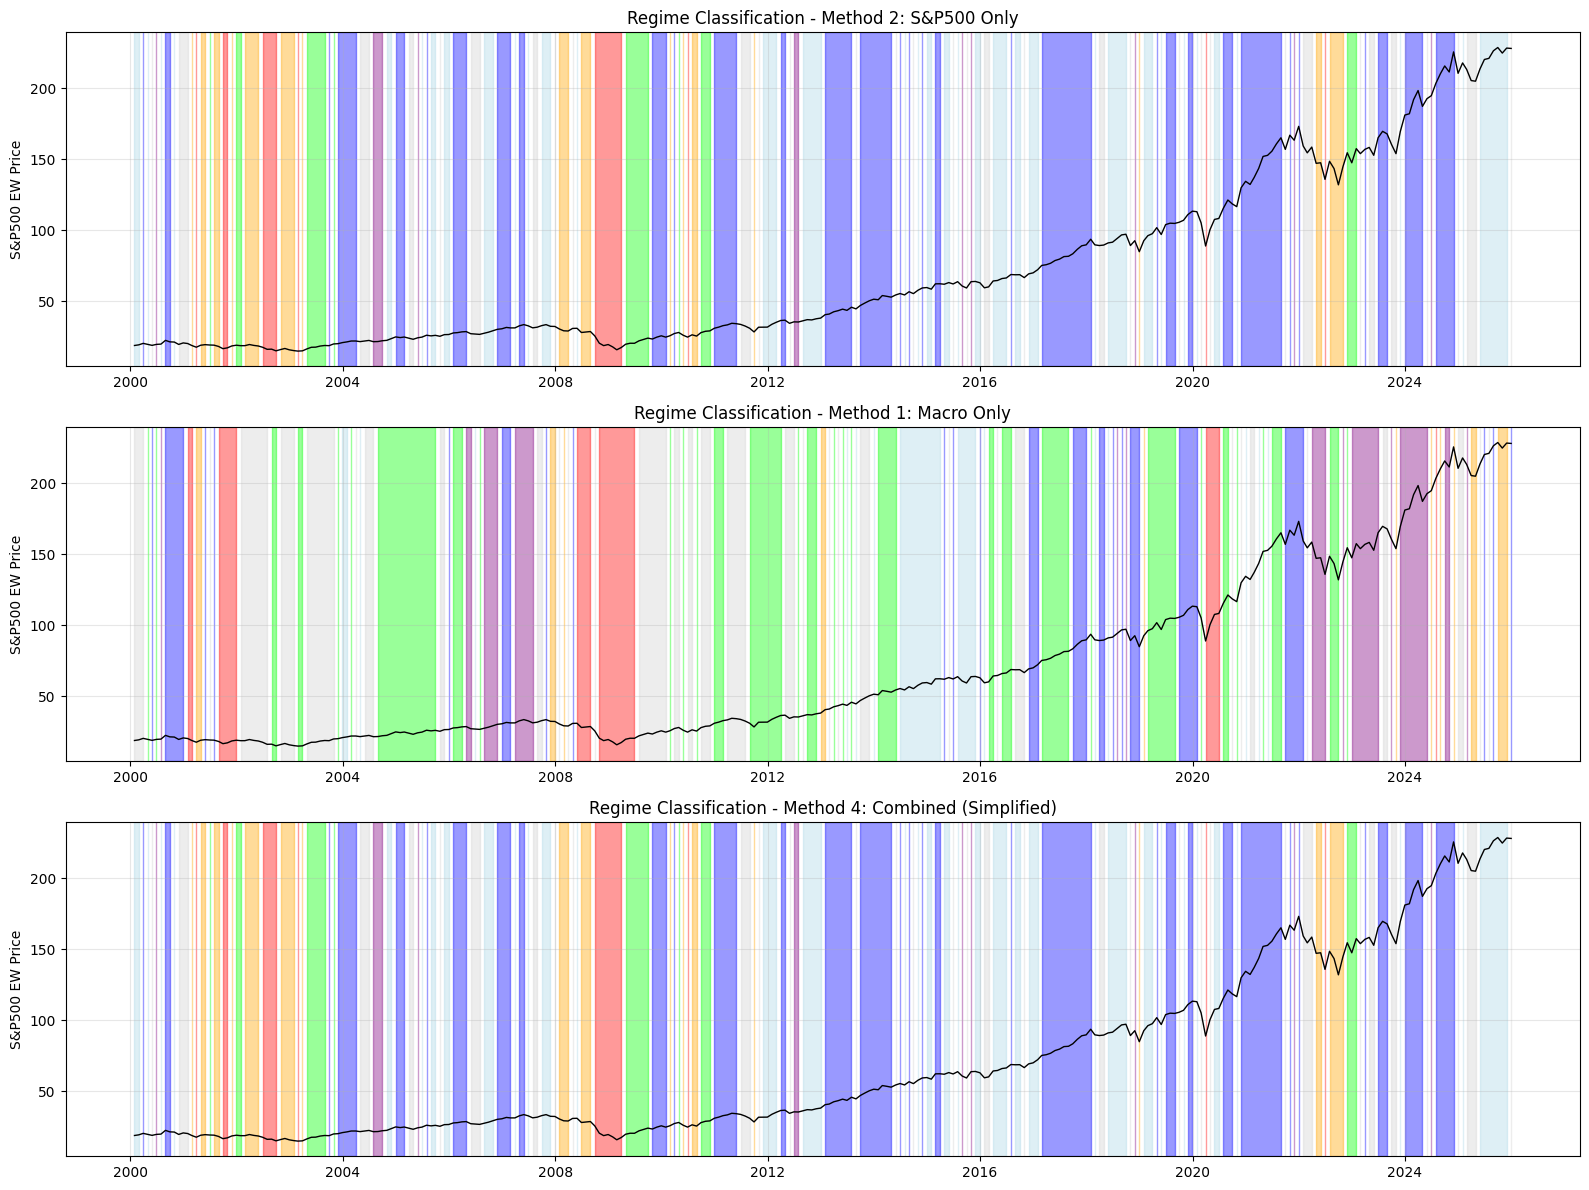


 Saved: regime_indicators_combined.parquet
   Columns: ['regime_v2', 'regime_v3', 'regime_macro', 'regime_combined', 'regime_simple']

 Done!


In [14]:
# =========================================
# [셀 6] 방법 4: 거시지표 + S&P500 조합
# =========================================
# 목적:
#   - 거시지표(후행)와 S&P500(선행) 장점 결합
#   - 두 방법이 일치할 때 더 확실한 레짐 판단
#   - 불일치 시 어떤 방법 우선할지 규칙 설정
#
# 조합 논리:
#   - 둘 다 Crash -> 확실한 Crash
#   - S&P500=Recovery + 거시=Crash -> S&P500 우선 (시장이 먼저 반응)
#   - S&P500=Expansion + 거시=Peak -> 주의 신호 (Peak_Warning)
#   - 둘 다 Expansion -> 확실한 Expansion

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

QP2_ROOT = Path(r"C:\QP2")
INTERIM_DIR = QP2_ROOT / "data" / "interim"

# -----------------------------
# 데이터 로드
# -----------------------------
print("="*60)
print("[Cell 6] Method 4: Macro + S&P500 Combined")
print("="*60)

macro = pd.read_parquet(INTERIM_DIR / "macro_indicators.parquet")
market = pd.read_parquet(INTERIM_DIR / "market_regime_indicators.parquet")

# 병합
combined = market[["regime_v2", "regime_v3"]].join(macro[["regime_macro"]], how="inner")
print(f"\n Combined data: {len(combined)} months")

# -----------------------------
# 조합 규칙 정의
# -----------------------------
print("\n Applying combination rules...")

def combine_regimes(row):
    """
    거시지표 + S&P500 조합 규칙
    
    원칙:
    1) 시장(S&P500)이 더 빠르게 반응 -> 전환점에서는 S&P500 우선
    2) 거시지표가 확인해주면 -> 더 확실
    3) 둘이 반대면 -> 주의 신호 또는 S&P500 우선
    """
    sp = row["regime_v2"]      # S&P500 기반
    macro = row["regime_macro"] # 거시지표 기반
    
    # =====================
    # Case 1: 둘 다 일치 -> 확실
    # =====================
    if sp == macro:
        return sp + "_Confirmed"
    
    # =====================
    # Case 2: Crash 관련
    # =====================
    # 둘 다 Crash 계열 -> Crash
    if "Crash" in sp and "Crash" in macro:
        return "1_Crash_Confirmed"
    
    # S&P500=Crash, 거시=아직 -> Crash (시장이 먼저)
    if sp == "1_Crash" and macro in ["5_Expansion", "6_Peak", "0_Neutral"]:
        return "1_Crash_Early"  # 시장은 빠졌는데 거시는 아직
    
    # S&P500=Recovery, 거시=Crash -> Recovery (시장이 먼저 반등)
    if sp == "2_Recovery_Early" and macro == "1_Crash":
        return "2_Recovery_Early"  # S&P500 우선
    
    # =====================
    # Case 3: Recovery 관련
    # =====================
    # S&P500=Recovery, 거시=Recovery -> 확실한 Recovery
    if "Recovery" in sp and "Recovery" in macro:
        return sp + "_Confirmed"
    
    # S&P500=Recovery_Late, 거시=Recovery_Early -> 전환 중
    if sp == "4_Recovery_Late" and macro == "2_Recovery_Early":
        return "4_Recovery_Late"  # S&P500 우선
    
    # =====================
    # Case 4: Expansion 관련
    # =====================
    # S&P500=Expansion, 거시=Expansion -> 확실
    if sp == "5_Expansion" and macro == "5_Expansion":
        return "5_Expansion_Confirmed"
    
    # S&P500=Expansion, 거시=Peak -> 주의
    if sp == "5_Expansion" and macro == "6_Peak":
        return "5_Expansion_Warning"  # 거시가 경고
    
    # S&P500=Expansion, 거시=뒤처짐 -> Expansion
    if sp == "5_Expansion" and macro in ["4_Recovery_Late", "2_Recovery_Early"]:
        return "5_Expansion"  # S&P500 우선
    
    # =====================
    # Case 5: Peak 관련
    # =====================
    # S&P500=Peak, 거시=Peak -> 확실한 Peak
    if sp == "6_Peak" and macro == "6_Peak":
        return "6_Peak_Confirmed"
    
    # S&P500=Peak, 거시=Expansion -> Peak (시장이 먼저 꺾임)
    if sp == "6_Peak" and macro == "5_Expansion":
        return "6_Peak_Early"
    
    # =====================
    # Case 6: Contraction 관련
    # =====================
    if sp == "3_Contraction" and macro == "3_Contraction":
        return "3_Contraction_Confirmed"
    
    if sp == "3_Contraction" and macro in ["1_Crash", "2_Recovery_Early"]:
        return "3_Contraction"  # S&P500 우선
    
    # =====================
    # Case 7: 기타 불일치 -> S&P500 우선 + 태그
    # =====================
    return sp + "_Unconfirmed"

combined["regime_combined"] = combined.apply(combine_regimes, axis=1)

# -----------------------------
# 분포 확인
# -----------------------------
print("\n" + "="*60)
print("Combined Regime Distribution")
print("="*60)

regime_dist = combined["regime_combined"].value_counts().sort_index()
total = len(combined)

print(f"\n{'Regime':<30} {'Count':>6} {'Pct':>8}")
print("-"*50)
for regime, count in regime_dist.items():
    pct = count / total * 100
    print(f"{regime:<30} {count:>6} ({pct:>5.1f}%)")

# -----------------------------
# 확인 비율 계산
# -----------------------------
confirmed = combined["regime_combined"].str.contains("Confirmed").sum()
warning = combined["regime_combined"].str.contains("Warning").sum()
early = combined["regime_combined"].str.contains("Early").sum()
unconfirmed = combined["regime_combined"].str.contains("Unconfirmed").sum()

print(f"\n Summary:")
print(f"   Confirmed (both agree):  {confirmed:>4} ({confirmed/total*100:>5.1f}%)")
print(f"   Warning (macro warns):   {warning:>4} ({warning/total*100:>5.1f}%)")
print(f"   Early (market leads):    {early:>4} ({early/total*100:>5.1f}%)")
print(f"   Unconfirmed (disagree):  {unconfirmed:>4} ({unconfirmed/total*100:>5.1f}%)")

# -----------------------------
# 주요 이벤트 확인
# -----------------------------
print("\n" + "="*60)
print("Key Events - Combined Regime")
print("="*60)

events = {
    "GFC Start": "2008-09-30",
    "GFC Bottom": "2009-03-31",
    "GFC Rebound": "2009-06-30",
    "Covid Crash": "2020-03-31",
    "Covid Rebound": "2020-04-30",
    "Covid Recovery": "2020-09-30",
    "Rate Hike Start": "2022-01-31",
    "Rate Hike Bottom": "2022-10-31",
    "Current": combined.index.max().strftime("%Y-%m-%d"),
}

print(f"\n{'Event':<18} {'S&P500':<18} {'Macro':<18} {'Combined':<25}")
print("-"*80)

for event_name, date_str in events.items():
    try:
        date = pd.to_datetime(date_str)
        idx = combined.index[combined.index <= date].max()
        sp = combined.loc[idx, "regime_v2"]
        macro = combined.loc[idx, "regime_macro"]
        comb = combined.loc[idx, "regime_combined"]
        print(f"{event_name:<18} {sp:<18} {macro:<18} {comb:<25}")
    except:
        print(f"{event_name:<18} {'N/A':<18} {'N/A':<18} {'N/A':<25}")

# -----------------------------
# 단순화 버전 (태그 제거)
# -----------------------------
print("\n Creating simplified version...")

def simplify_regime(regime):
    """Confirmed, Warning 등 태그 제거하고 기본 레짐만"""
    for base in ["1_Crash", "2_Recovery_Early", "3_Contraction", 
                 "4_Recovery_Late", "5_Expansion", "6_Peak", "0_Neutral"]:
        if regime.startswith(base):
            return base
    return "0_Neutral"

combined["regime_simple"] = combined["regime_combined"].apply(simplify_regime)

print("\n Simplified Distribution:")
simple_dist = combined["regime_simple"].value_counts().sort_index()
for regime, count in simple_dist.items():
    pct = count / total * 100
    print(f"   {regime:<20} {count:>6} ({pct:>5.1f}%)")

# -----------------------------
# 시각화
# -----------------------------
print("\n Generating charts...")

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

regime_colors = {
    "0_Neutral": "lightgray",
    "1_Crash": "red",
    "2_Recovery_Early": "lime",
    "3_Contraction": "orange",
    "4_Recovery_Late": "lightblue",
    "5_Expansion": "blue",
    "6_Peak": "purple",
}

# 가격 데이터 로드
market_full = pd.read_parquet(INTERIM_DIR / "market_regime_indicators.parquet")

for ax_idx, (regime_col, title) in enumerate([
    ("regime_v2", "Method 2: S&P500 Only"),
    ("regime_macro", "Method 1: Macro Only"),
    ("regime_simple", "Method 4: Combined (Simplified)")
]):
    ax = axes[ax_idx]
    
    # 해당 레짐 컬럼이 있는 데이터 선택
    if regime_col in combined.columns:
        plot_data = combined
    else:
        plot_data = combined
    
    # 가격 플롯
    common_idx = market_full.index.intersection(plot_data.index)
    ax.plot(common_idx, market_full.loc[common_idx, "price"], color="black", linewidth=1)
    ax.set_ylabel("S&P500 EW Price")
    ax.set_title(f"Regime Classification - {title}")
    
    # 레짐 배경
    plot_data["_shift"] = plot_data[regime_col] != plot_data[regime_col].shift(1)
    plot_data["_group"] = plot_data["_shift"].cumsum()
    
    for group_id, group_df in plot_data.groupby("_group"):
        regime = group_df[regime_col].iloc[0]
        # 단순화된 레짐으로 색상 찾기
        base_regime = simplify_regime(regime) if "Confirmed" in regime or "Warning" in regime or "Early" in regime else regime
        color = regime_colors.get(base_regime, "white")
        ax.axvspan(group_df.index.min(), group_df.index.max(), alpha=0.4, color=color)
    
    ax.grid(True, alpha=0.3)
    
    plot_data.drop(columns=["_shift", "_group"], inplace=True)

plt.tight_layout()
plt.show()

# -----------------------------
# 저장
# -----------------------------
combined.to_parquet(INTERIM_DIR / "regime_indicators_combined.parquet")
print(f"\n Saved: regime_indicators_combined.parquet")
print(f"   Columns: {list(combined.columns)}")

print("\n Done!")

In [15]:
# =========================================
# [셀 6-1] 조합 결과 상세 확인
# =========================================

import pandas as pd
from pathlib import Path

QP2_ROOT = Path(r"C:\QP2")
INTERIM_DIR = QP2_ROOT / "data" / "interim"

combined = pd.read_parquet(INTERIM_DIR / "regime_indicators_combined.parquet")

# -----------------------------
# Summary
# -----------------------------
print("="*60)
print("Summary")
print("="*60)

total = len(combined)
confirmed = combined["regime_combined"].str.contains("Confirmed").sum()
warning = combined["regime_combined"].str.contains("Warning").sum()
early = combined["regime_combined"].str.contains("Early").sum()
unconfirmed = combined["regime_combined"].str.contains("Unconfirmed").sum()
other = total - confirmed - warning - early - unconfirmed

print(f"   Confirmed (both agree):  {confirmed:>4} ({confirmed/total*100:>5.1f}%)")
print(f"   Warning (macro warns):   {warning:>4} ({warning/total*100:>5.1f}%)")
print(f"   Early (market leads):    {early:>4} ({early/total*100:>5.1f}%)")
print(f"   Unconfirmed (disagree):  {unconfirmed:>4} ({unconfirmed/total*100:>5.1f}%)")
print(f"   Other (no tag):          {other:>4} ({other/total*100:>5.1f}%)")

# -----------------------------
# Key Events
# -----------------------------
print("\n" + "="*60)
print("Key Events - Combined Regime")
print("="*60)

events = {
    "GFC Start": "2008-09-30",
    "GFC Bottom": "2009-03-31",
    "GFC Rebound": "2009-06-30",
    "Covid Crash": "2020-03-31",
    "Covid Rebound": "2020-04-30",
    "Covid Recovery": "2020-09-30",
    "Rate Hike Start": "2022-01-31",
    "Rate Hike Bottom": "2022-10-31",
    "Current": combined.index.max().strftime("%Y-%m-%d"),
}

print(f"\n{'Event':<18} {'S&P500':<18} {'Macro':<18} {'Combined':<28}")
print("-"*85)

for event_name, date_str in events.items():
    try:
        date = pd.to_datetime(date_str)
        idx = combined.index[combined.index <= date].max()
        sp = combined.loc[idx, "regime_v2"]
        macro = combined.loc[idx, "regime_macro"]
        comb = combined.loc[idx, "regime_combined"]
        print(f"{event_name:<18} {sp:<18} {macro:<18} {comb:<28}")
    except Exception as e:
        print(f"{event_name:<18} Error: {e}")

# -----------------------------
# Simplified Distribution
# -----------------------------
print("\n" + "="*60)
print("Simplified Distribution")
print("="*60)

simple_dist = combined["regime_simple"].value_counts().sort_index()
print(f"\n{'Regime':<20} {'Count':>6} {'Pct':>8}")
print("-"*40)
for regime, count in simple_dist.items():
    pct = count / total * 100
    print(f"{regime:<20} {count:>6} ({pct:>5.1f}%)")

# -----------------------------
# 전체 분포 (태그 포함)
# -----------------------------
print("\n" + "="*60)
print("Full Distribution (with tags)")
print("="*60)

full_dist = combined["regime_combined"].value_counts().sort_index()
print(f"\n{'Regime':<35} {'Count':>6} {'Pct':>8}")
print("-"*55)
for regime, count in full_dist.items():
    pct = count / total * 100
    print(f"{regime:<35} {count:>6} ({pct:>5.1f}%)")

Summary
   Confirmed (both agree):    63 ( 20.2%)
   Warning (macro warns):     13 (  4.2%)
   Early (market leads):      29 (  9.3%)
   Unconfirmed (disagree):   160 ( 51.3%)
   Other (no tag):            47 ( 15.1%)

Key Events - Combined Regime

Event              S&P500             Macro              Combined                    
-------------------------------------------------------------------------------------
GFC Start          1_Crash            0_Neutral          1_Crash_Early               
GFC Bottom         1_Crash            1_Crash            1_Crash_Confirmed           
GFC Rebound        2_Recovery_Early   1_Crash            2_Recovery_Early            
Covid Crash        1_Crash            1_Crash            1_Crash_Confirmed           
Covid Rebound      0_Neutral          1_Crash            0_Neutral_Unconfirmed       
Covid Recovery     5_Expansion        0_Neutral          5_Expansion_Unconfirmed     
Rate Hike Start    0_Neutral          5_Expansion        0_Neut

In [16]:
# Macro Warning 떴던 시점 확인
warning_months = combined[combined["regime_combined"].str.contains("Warning")]
print(warning_months.index.tolist())

[Timestamp('2006-04-30 00:00:00'), Timestamp('2006-11-30 00:00:00'), Timestamp('2007-04-30 00:00:00'), Timestamp('2007-05-31 00:00:00'), Timestamp('2023-03-31 00:00:00'), Timestamp('2023-06-30 00:00:00'), Timestamp('2023-12-31 00:00:00'), Timestamp('2024-01-31 00:00:00'), Timestamp('2024-02-29 00:00:00'), Timestamp('2024-03-31 00:00:00'), Timestamp('2024-04-30 00:00:00'), Timestamp('2024-09-30 00:00:00'), Timestamp('2024-10-31 00:00:00')]


In [18]:
# =========================================
# [셀 7] 01_DataLoader_Macro.ipynb 최종 정리
# =========================================
#
# =============================================================================
# REGIME CLASSIFICATION — FINAL SUMMARY
# =============================================================================
#
# 1. 노트북 목적
# --------------
# 비즈니스 사이클 기반 시장 레짐 분류
# 팩터 타이밍 전략의 기초 데이터 생성
#
#
# =============================================================================
# 2. 생성된 레짐 분류 (4가지 방법)
# =============================================================================
#
# [방법 1] regime_macro — 거시지표 기반
#     사용 지표: 실업률, 금리차, 스프레드, 소비자심리, 기준금리
#     특징: 후행성 있음 (특히 실업률)
#     용도: 과거 레짐 분류, 확인용
#
# [방법 2] regime_v2 — S&P500 기반
#     사용 지표: MA대비 위치, 모멘텀(3M/6M), Drawdown, Rally
#     특징: 시장 반응 즉시 반영
#     용도: 실시간 판단, 팩터 테스트 기본
#
# [방법 3] regime_v3 — S&P500 + 전환분리
#     방법 2 + 주요 전환점 첫 달에 _Trans 태그
#     용도: 전환 초기 급변동 구간 별도 분석
#
# [방법 4] regime_combined — 거시 + S&P500 조합
#     태그: Confirmed, Warning, Early, Unconfirmed
#     용도: 두 방법 일치 여부로 확신도 판단
#
#
# =============================================================================
# 3. 레짐 정의
# =============================================================================
#
# 0_Neutral: 애매한 구간 (조건 미충족)
# 1_Crash: 급락 진행 중 (DD < -18%, mom_3m < -7%)
# 2_Recovery_Early: 바닥 찍고 급반등 (DD < -8%, mom_3m > +7%)
# 3_Contraction: 하락/침체 지속 (MA 아래, 모멘텀 약함)
# 4_Recovery_Late: 회복 안정화 (MA 근처, 모멘텀 양수)
# 5_Expansion: 확장기 (MA 위, 모멘텀 양수)
# 6_Peak: 고점, 모멘텀 약화 (MA 위, 모멘텀 꺾임)
#
#
# =============================================================================
# 4. 방법별 분포 비교 (2000-2025, 312개월)
# =============================================================================
#
# 레짐               방법1(거시)      방법2(S&P500)    방법4(조합)
# ------------------------------------------------------------------
# 0_Neutral          77 (24.7%)      148 (19.2%)      51 (16.3%)
# 1_Crash            25 ( 8.0%)       42 ( 5.5%)      18 ( 5.8%)
# 2_Recovery_Early   84 (26.9%)       54 ( 7.0%)      22 ( 7.1%)
# 3_Contraction      17 ( 5.4%)       81 (10.5%)      33 (10.6%)
# 4_Recovery_Late    28 ( 9.0%)      153 (19.9%)      37 (11.9%)
# 5_Expansion        44 (14.1%)      249 (32.4%)     144 (46.2%)
# 6_Peak             37 (11.9%)       42 ( 5.5%)      24 ( 7.7%)
#
#
# =============================================================================
# 5. 조합 레짐 태그 의미
# =============================================================================
#
# _Confirmed: 둘 다 동의 (20.2%) — 확실한 레짐
# _Warning: 거시가 경고 (4.2%) — 시장 좋지만 펀더멘털 과열
# _Early: 시장이 먼저 (9.3%) — 시장 선행, 거시 후행
# _Unconfirmed: 불일치 (51.3%) — S&P500 기준 우선 적용
# (태그 없음): 기타 (15.1%)
#
#
# =============================================================================
# 6. 주요 이벤트 레짐 판단
# =============================================================================
#
# 이벤트              S&P500           Macro            Combined
# ------------------------------------------------------------------
# GFC Start          1_Crash          0_Neutral        1_Crash_Early
# GFC Bottom         1_Crash          1_Crash          1_Crash_Confirmed
# GFC Rebound        2_Recovery_Early 1_Crash          2_Recovery_Early
# Covid Crash        1_Crash          1_Crash          1_Crash_Confirmed
# Covid Rebound      0_Neutral        1_Crash          0_Neutral_Unconfirmed
# Rate Hike Bottom   3_Contraction    6_Peak           3_Contraction_Unc
#
#
# =============================================================================
# 7. Macro Warning 분석 (흥미로운 발견)
# =============================================================================
#
# Warning 발생 시점:
#     2006-04, 2006-11, 2007-04, 2007-05 — GFC 직전 (1-2년 전)
#     2023-03, 2023-06, 2023-12 — 최근
#     2024-01, 02, 03, 04, 09, 10 — 현재 진행 중
#
# 해석:
#     시장(S&P500)은 Expansion인데, 거시지표는 Peak 신호
#     "시장 좋아 보이지만 펀더멘털 과열 주의"
#
# 2006-2007 사례:
#     Warning 뜨고 1-2년 후 GFC 터짐 — 실제로 맞았음
#
# 2023-2024 현재:
#     Warning 계속 발생 중 — 주의 필요
#
#
# =============================================================================
# 8. 각 방법의 한계
# =============================================================================
#
# [방법 1] 거시지표
#     - 실업률 후행 -> 시장보다 늦게 반응
#     - 예측용 부적합 (과거 분류용)
#     - 개선: 실업률 빼고 금리차+스프레드+VIX 위주로
#
# [방법 2] S&P500
#     - 미래정보 사용 위험 (백테스트 시 look-ahead bias)
#     - 노이즈에 민감 (레짐 자주 바뀜)
#     - 개선: 거시지표와 결합해서 확인
#
# [방법 4] 조합
#     - 51% 불일치 -> 완벽한 조합 아님
#     - 복잡함 (태그 많음)
#     - 용도: 확신도 판단용, 최종 레짐은 S&P500 기준
#
#
# =============================================================================
# 9. 저장된 파일
# =============================================================================
#
# data/interim/macro_indicators.parquet
#     컬럼: UNRATE, INDPRO, UMCSENT, BAAFFM, T10Y2Y, FEDFUNDS, VIXCLS
#           + 변화율 컬럼들 + regime_macro
#     기간: 2000-01 ~ 2025-12
#
#  data/interim/market_regime_indicators.parquet
#     컬럼: price, ma_6m, ma_12m, price_vs_ma, mom_1m/3m/6m/12m,
#           volatility, drawdown, rally_from_low, ma_slope
#           + regime, regime_v2, regime_v3, regime_final
#     기간: 1962-01 ~ 2025-12 (초기 NaN 있음)
#     용도: 방법 2 (S&P500 기반), 방법 3 (Trans 분리)
#
# data/interim/regime_indicators_combined.parquet
#     컬럼: regime_v2, regime_v3, regime_macro, regime_combined, regime_simple
#     기간: 2000-01 ~ 2025-12 (거시지표 시작 이후)
#
#
# =============================================================================
# 10. 다음 단계
# =============================================================================
#
# 1) 02_Factor 노트북에서 레짐별 팩터 테스트
#    - 각 레짐에서 Value, Momentum 등 팩터 유효성 검증
#    - regime_v2 또는 regime_simple 사용 권장
#
# 2) 레짐 기반 팩터 타이밍 전략
#    - Crash/Recovery_Early: 팩터 A 비중 높임
#    - Expansion: 팩터 B 비중 높임
#    - Peak/Warning: 방어적 포지션
#
# 3) Walk-forward 백테스트
#    - 과거 레짐으로 학습 -> 미래 레짐 예측 -> 팩터 비중 조정
#
# =============================================================================

print("Cell 7: Final summary (documentation only)")
print("See comments above for full documentation")
print("")
print("Files saved:")
print("  - data/interim/macro_indicators.parquet")
print("  - data/interim/market_regime_indicators.parquet")
print("  - data/interim/regime_indicators_combined.parquet")

Cell 7: Final summary (documentation only)
See comments above for full documentation

Files saved:
  - data/interim/macro_indicators.parquet
  - data/interim/market_regime_indicators.parquet
  - data/interim/regime_indicators_combined.parquet
